<a href="https://colab.research.google.com/github/MediaUpScale/Endless-Summers-Paradise/blob/main/Video_Factory_Mediaupscale_V1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
import os
from google.colab import drive

def setup_drive_and_factory():
    """
    Monta o Drive e localiza a pasta MEDIAUPSCALE_FACTORY dentro de Colab Notebooks.
    Caminho validado via print do utilizador.
    """
    try:
        # 1. Montagem do Drive
        if not os.path.exists('/content/drive'):
            print("🚀 Montando Google Drive...")
            drive.mount('/content/drive')
        else:
            print("✅ Google Drive já está montado.")

        # 2. Caminho exacto baseado no print image_66b2c2.png
        # O atalho está dentro de 'Meu Drive > Colab Notebooks'
        target_path = "/content/drive/MyDrive/Colab Notebooks/MEDIAUPSCALE_FACTORY"

        print(f"🔍 Procurando pasta em: {target_path}")

        if os.path.exists(target_path):
            print(f"✅ Sucesso! Pasta de produção localizada no diretório do Colab.")
            return target_path
        else:
            # Caso o atalho tenha sido movido, fazemos uma busca rápida
            print("⚠️ Atalho não encontrado no caminho específico. A procurar no Drive...")
            for root, dirs, files in os.walk('/content/drive/MyDrive'):
                if 'MEDIAUPSCALE_FACTORY' in dirs:
                    found = os.path.join(root, 'MEDIAUPSCALE_FACTORY')
                    print(f"✅ Pasta encontrada em: {found}")
                    return found

            # Se falhar totalmente, cria na raiz por segurança
            fallback = "/content/drive/MyDrive/MEDIAUPSCALE_FACTORY"
            os.makedirs(fallback, exist_ok=True)
            print(f"📁 Pasta não localizada. Criada nova em: {fallback}")
            return fallback

    except Exception as e:
        print(f"❌ Erro de Sistema: {e}")
        return "/content"

# Define a variável global BASE_PATH para as próximas células
BASE_PATH = setup_drive_and_factory()

✅ Google Drive já está montado.
🔍 Procurando pasta em: /content/drive/MyDrive/Colab Notebooks/MEDIAUPSCALE_FACTORY
✅ Sucesso! Pasta de produção localizada no diretório do Colab.


✅ Motor Ativo: models/gemini-2.5-pro + models/gemini-3-pro-image-preview
🧠 Cérebro (models/gemini-2.5-pro): Gerando roteiro com abertura em plano aberto...
🚀 Produzindo a 'Establishing Shot' do Parque...
📸 Visual (models/gemini-3-pro-image-preview): Gerando Cena 1 (Foco: Plano Aberto)...


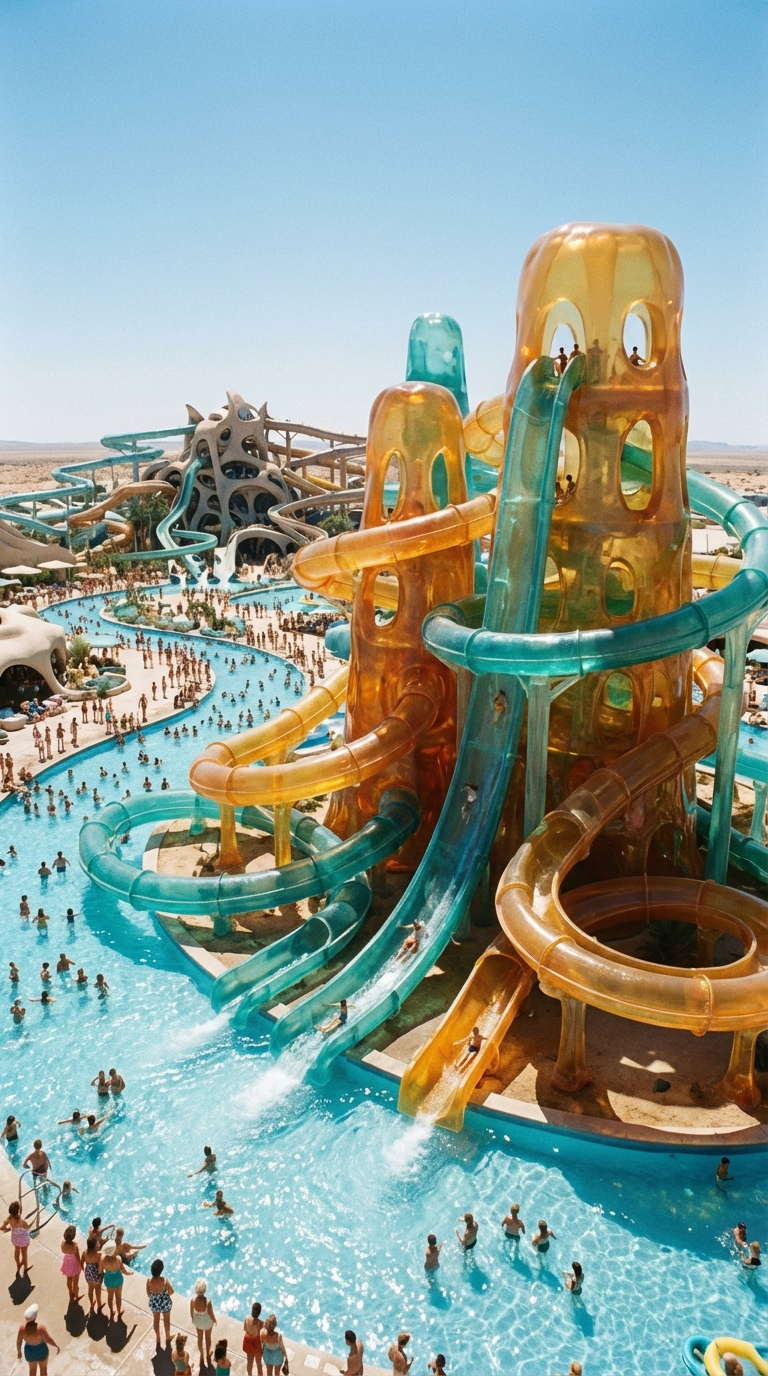


✅ PLANO ABERTO FINALIZADO.
📍 Ficheiro guardado em: /content/drive/MyDrive/Colab Notebooks/MEDIAUPSCALE_FACTORY/Endless_Summers_Paradise/Elite_V6_Ultra_HighRes


In [1]:
import os
import requests
import json
import base64
import time
import re
from google.colab import drive, userdata
from IPython.display import Image, display

# --- [1. CONFIGURAÇÃO DO PROJETO E MATERIAIS] ---
PROJECT_CONFIG = {
    "root_folder": "Endless_Summers_Paradise",
    "project_name": "Elite_V6_Ultra_HighRes",   # Versão focada em Resolução Máxima
    "theme": "Endless Summer - Colossal surreal water park, hyper-realistic candid photography.",
    "material_water": "Ultra-viscous glowing gummy liquid, heavy syrup physics, internal light scattering, 8k water surface detail.",
    "material_structures": "Massive semi-translucent Jell-O architectural slides, wobbly but structural, high-fidelity surface texture.",
    "persona": "Athletic women, 1950s style, natural unedited skin, visible pores, sweat, realistic body proportions, vintage swimwear.",
    "lighting": "Hard natural sunlight, 12pm high-noon shadows, bright clear sky, cinematic exposure.",
    "aspect_ratio": "9:16",
    "scene_count": 10
}

# --- [2. SETUP DE INFRAESTRUTURA E DRIVE] ---
def setup_environment():
    try:
        if not os.path.exists('/content/drive'):
            print("🚀 A montar o Google Drive...")
            drive.mount('/content/drive')

        base_factory = "/content/drive/MyDrive/Colab Notebooks/MEDIAUPSCALE_FACTORY"
        if not os.path.exists(base_factory):
            base_factory = "/content/drive/MyDrive/MEDIAUPSCALE_FACTORY"

        root_path = os.path.join(base_factory, PROJECT_CONFIG["root_folder"])
        if not os.path.exists(root_path):
            os.makedirs(root_path, exist_ok=True)

        project_dir = os.path.join(root_path, PROJECT_CONFIG["project_name"])
        if not os.path.exists(project_dir):
            os.makedirs(project_dir, exist_ok=True)
            print(f"📂 Pasta de Produção HQ Criada: {project_dir}")

        return project_dir
    except Exception as e:
        print(f"❌ Erro no Setup: {e}")
        return "/content"

# --- [3. MOTOR DE INTELIGÊNCIA - ELITE IMAGE LOCK] ---
API_KEY = userdata.get('GOOGLE_API_KEY')

def get_validated_models():
    # Fixando o modelo Gemini 3 Pro Image para evitar downgrades
    selected_brain = "models/gemini-2.5-pro"
    selected_image = "models/gemini-3-pro-image-preview"
    return selected_brain, selected_image

MODEL_BRAIN, MODEL_IMAGE = get_validated_models()

# --- [4. FUNÇÕES DE GERAÇÃO CINEMATOGRÁFICA] ---

def call_gemini_api(url, payload, max_retries=5):
    for i in range(max_retries):
        try:
            res = requests.post(url, json=payload, timeout=120).json()
            if 'candidates' in res and res['candidates']:
                return res
        except: pass
        time.sleep(2 ** i)
    return None

def generate_full_script(project_dir):
    url = f"https://generativelanguage.googleapis.com/v1beta/{MODEL_BRAIN}:generateContent?key={API_KEY}"

    # Roteiro ajustado para forçar a abertura da primeira cena
    prompt = f"""
    [ACTOR: MASTER CINEMATOGRAPHER]
    Create a 10-scene JSON script for '{PROJECT_CONFIG['theme']}'.

    STRICT CINEMATIC RULE FOR SCENE 1:
    - Scene 1 MUST be an 'Extreme Wide Shot' or 'Aerial Master View'.
    - It must show the colossal scale of the park, multiple slides, towers, and huge crowds.
    - Focus on the architecture and the 'Establishing Shot' of the paradise.
    - Subsequent scenes can then zoom into the details (sweat, pores, sliding action).

    Output ONLY valid JSON:
    {{ "episode": "{PROJECT_CONFIG['project_name']}", "storyboard": [{{ "scene_id": 1, "title": "string", "image_prompt": "string", "video_command": "string", "audio_desc": "string" }}] }}
    """

    payload = {"contents": [{"parts": [{"text": prompt}]}], "generationConfig": {"responseMimeType": "application/json"}}

    try:
        print(f"🧠 Cérebro ({MODEL_BRAIN}): Gerando roteiro com abertura em plano aberto...")
        res = call_gemini_api(url, payload)
        if not res: return None

        script_text = res['candidates'][0]['content']['parts'][0]['text']
        script = json.loads(re.sub(r'```json\n?|```', '', script_text).strip())

        path = os.path.join(project_dir, "script_hq.json")
        with open(path, "w", encoding='utf-8') as f:
            json.dump(script, f, indent=4, ensure_ascii=False)
        return script
    except Exception as e:
        print(f"❌ Erro no roteiro: {e}")
        return None

def generate_elite_image(scene_data, project_dir):
    """Gera o Master Frame com foco em escala (Cena 1) ou detalhe (restantes)."""
    url = f"https://generativelanguage.googleapis.com/v1beta/{MODEL_IMAGE}:generateContent?key={API_KEY}"

    # Se for a cena 1, injetamos comandos de "Plano Aberto"
    composition_bonus = ""
    if scene_data['scene_id'] == 1:
        composition_bonus = "WIDE ANGLE AERIAL VIEW. Establishing shot showing the whole park scale. Distant architecture, massive slides, thousands of people. Scale comparison."
    else:
        composition_bonus = "MEDIUM CLOSE-UP. Focus on the characters and action."

    elite_prompt = (
        f"9:16 VERTICAL. {composition_bonus}. {scene_data['image_prompt']}. "
        f"ULTRA-HIGH RESOLUTION. Sharp focus on distant structures. "
        f"Authentic 35mm film photography, Kodak Portra 400. "
        f"Materials: {PROJECT_CONFIG['material_water']}, {PROJECT_CONFIG['material_structures']}. "
        f"Persona: {PROJECT_CONFIG['persona']} visible in the environment. "
        f"STRICTLY NO CGI LOOK. REALISTIC PHOTOGRAPHY."
    )

    payload = {
        "contents": [{"parts": [{"text": elite_prompt}]}],
        "generationConfig": {
            "responseModalities": ["IMAGE"]
        }
    }

    try:
        scene_id = scene_data['scene_id']
        print(f"📸 Visual ({MODEL_IMAGE}): Gerando Cena {scene_id} (Foco: {'Plano Aberto' if scene_id == 1 else 'Ação/Zoom'})...")
        res = call_gemini_api(url, payload)

        if not res: return None

        parts = res['candidates'][0].get('content', {}).get('parts', [])
        img_part = next((p for p in parts if 'inlineData' in p), None)

        if not img_part: return None

        img_b64 = img_part['inlineData']['data']
        save_path = os.path.join(project_dir, f"scene_{scene_id}_ULTRA_HQ.png")

        with open(save_path, "wb") as f:
            f.write(base64.b64decode(img_b64))
        return img_b64

    except Exception as e:
        print(f"❌ Erro visual: {e}")
        return None

# --- [5. EXECUÇÃO] ---
def start_production():
    target_dir = setup_environment()
    print(f"✅ Motor Ativo: {MODEL_BRAIN} + {MODEL_IMAGE}")

    script = generate_full_script(target_dir)
    if script:
        # Gerar a Cena 1 (O Plano Aberto)
        first_scene = script['storyboard'][0]
        print(f"🚀 Produzindo a 'Establishing Shot' do Parque...")

        img_data = generate_elite_image(first_scene, target_dir)
        if img_data:
            display(Image(data=base64.b64decode(img_data)))
            print(f"\n✅ PLANO ABERTO FINALIZADO.")
            print(f"📍 Ficheiro guardado em: {target_dir}")

if __name__ == "__main__":
    start_production()